<a href="https://colab.research.google.com/github/mhmmdrdhiansyah/data-science-2026/blob/main/Pertemuan9_Muhammad_Ardhiansyah_240401020092.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nama : Muhammad Ardhiansyah

nim : 240401020092

kelas : IF403

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Memuat dataset bawaan scikit-learn
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant (ganas), 1 = benign (jinak)


print('Shape dataset:', X.shape)
print('\nDistribusi kelas target (proporsi):')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape dataset: (569, 30)

Distribusi kelas target (proporsi):
1    0.627
0    0.373
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Memisahkan data latih dan uji (80:20) dengan stratifikasi target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Penskalaan fitur (Standardisasi) untuk model Logistic Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Data latih : {X_train.shape} baris")
print(f"Data uji   : {X_test.shape} baris")

Data latih : (455, 30) baris
Data uji   : (114, 30) baris


In [ ]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi dan pelatihan model Logistic Regression
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_s, y_train)

# Memprediksi kelas data uji
y_pred_log = log_model.predict(X_test_s)

# Menampilkan koefisien fitur yang paling berpengaruh
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print("=== 5 Fitur Paling Berpengaruh (Logistic Regression) ===")
print(coef_df.head())

=== 5 Fitur Paling Berpengaruh (Logistic Regression) ===
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


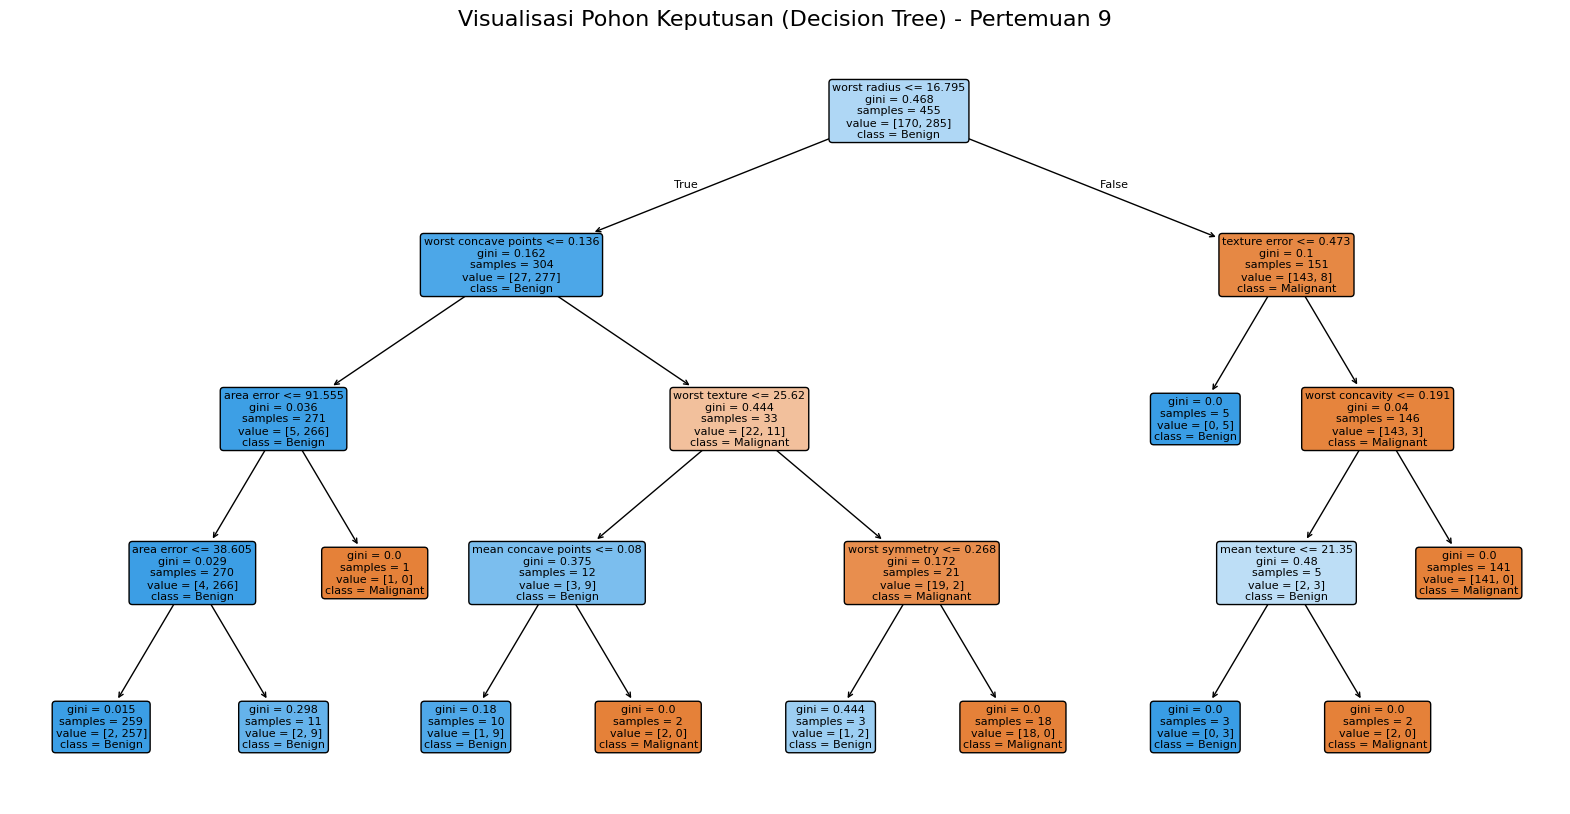

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Inisialisasi dan pelatihan model Decision Tree (kedalaman dibatasi)
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Memprediksi kelas data uji
y_pred_tree = tree_model.predict(X_test)

# Visualisasi pohon keputusan
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Malignant', 'Benign'],
    filled=True,
    rounded=True
)
plt.title("Visualisasi Pohon Keputusan (Decision Tree) - Pertemuan 9", fontsize=16)
plt.show()

In [ ]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

# Melakukan perulangan untuk mengevaluasi kedua model
for name, y_pred in [('Logistic Regression', y_pred_log),
                     ('Decision Tree', y_pred_tree)]:
    print(f"\n=== Evaluasi Model: {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision : {precision_score(y_test, y_pred):.3f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.3f}")


=== Evaluasi Model: Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy  : 0.982
Precision : 0.986
Recall    : 0.986
F1-Score  : 0.986

=== Evaluasi Model: Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy  : 0.939
Precision : 0.958
Recall    : 0.944
F1-Score  : 0.951


* data yang diload terdapat 569 baris data dan 30 kolom data. dari semua data tersebut proporsi nya adalah 62.7% untuk jinak dan 37.3% untuk ganas

* setelah itu data dibagi 2 dengan rasio 80:20. 80 data latih dan 20 data uji

* Dari hasil latih model Logistic Regression, kita dapat menyimpulkan bahwa model ini memiliki tingkat interpretabilitas yang sangat baik. Model berhasil mengidentifikasi bahwa tekstur yang kasar (worst texture koifisien -1,255), ketidakteraturan bentuk (radius error -1,082), banyaknya cekungan (worst concave points -0.953), serta ukuran sel yang membesar (worst area & worst radius -0,947) adalah indikator-indikator klinis paling dominan yang menandakan bahwa tumor pasien bersifat ganas (malignant).

* setlah itu dibuatkan model decision treenya agar dapat visualisasi faktor penentu dikategorikan ganas atau jinak. terlihat dari penentu paling utama adalah worst radius. pada cabang jinak jika dia berukuran kecil masih ada klasifikasi lain dibawah seperti worst concave points, area error, worst texture dan worst symmetry

*






